In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

In [2]:
gene_meta = pd.read_parquet('gene_metadata.parquet')
gene_meta = gene_meta.set_index('ensembl_id')
gene_meta = gene_meta[['gene_symbol']].to_dict()
len(gene_meta['gene_symbol'])

62710

cl3_10x

In [2]:
cl3_10x = pd.read_csv('./tian_data/sc_10x.count.csv')
# cl3_10x.index = cl3_10x.index.map(gene_meta['gene_symbol'])
# cl3_10x = cl3_10x[cl3_10x.index.notna()]
cl3_10x

,CELL_000001,CELL_000002,CELL_000003,CELL_000004,CELL_000005,CELL_000006,CELL_000007,CELL_000008,CELL_000009,CELL_000010,...,CELL_000931,CELL_000932,CELL_000933,CELL_000934,CELL_000935,CELL_000939,CELL_000943,CELL_000946,CELL_000955,CELL_000965
ENSG00000272758,0,0,0,2,0,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
ENSG00000154678,0,0,0,1,0,1,0,0,1,2,...,0,0,0,0,0,0,0,0,0,0
ENSG00000148737,0,0,0,1,3,2,0,2,1,0,...,0,0,0,2,0,4,0,0,2,0
ENSG00000196968,0,0,0,1,2,2,5,0,4,1,...,0,0,0,0,0,2,0,0,0,0
ENSG00000134297,0,0,0,1,1,1,2,1,3,0,...,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000237289,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ENSG00000238098,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,2,0,0
ENSG00000133433,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000054219,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
cl3_10x_meta = pd.read_csv('./tian_data/sc_10x.metadata.csv')
cl3_10x_meta = cl3_10x_meta[['cell_line_demuxlet']]
cl3_10x_meta

,cell_line_demuxlet
CELL_000001,HCC827
CELL_000002,HCC827
CELL_000003,HCC827
CELL_000004,HCC827
CELL_000005,HCC827
...,...
CELL_000939,H1975
CELL_000943,H1975
CELL_000946,H2228
CELL_000955,HCC827


cl3_celseq2

In [4]:
cl3_celseq2 = pd.read_csv('./tian_data/sc_celseq2.count.csv')
cl3_celseq2.index = cl3_celseq2.index.map(gene_meta['gene_symbol'])
cl3_celseq2 = cl3_celseq2[cl3_celseq2.index.notna()]
cl3_celseq2

,A1,A10,A11,A13,A14,A15,A16,A18,A2,A20,...,P18,P19,P20,P22,P4,P5,P6,P7,P8,P9
SCHLAP1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
LINC00310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
RN7SL288P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000284221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000272472,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDYL2,0,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
MIR6071,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000279274,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZNF462,0,3,2,3,4,2,3,3,3,1,...,2,2,1,1,3,5,2,1,1,5


In [5]:
cl3_celseq2_meta = pd.read_csv('./tian_data/sc_celseq2.metadata.csv')
cl3_celseq2_meta = cl3_celseq2_meta[['cell_line_demuxlet']]
cl3_celseq2_meta

,cell_line_demuxlet
A1,H1975
A10,H2228
A11,HCC827
A13,H2228
A14,HCC827
...,...
P5,HCC827
P6,H1975
P7,H1975
P8,H2228


cl3_dropseq

In [2]:
cl3_dropseq = pd.read_csv('./tian_data/sc_dropseq.count.csv')
# cl3_dropseq.index = cl3_dropseq.index.map(gene_meta['gene_symbol'])
# cl3_dropseq = cl3_dropseq[cl3_dropseq.index.notna()]
cl3_dropseq

,CELL_000001,CELL_000002,CELL_000003,CELL_000004,CELL_000005,CELL_000006,CELL_000007,CELL_000008,CELL_000009,CELL_000010,...,CELL_000228,CELL_000229,CELL_000230,CELL_000231,CELL_000233,CELL_000237,CELL_000238,CELL_000246,CELL_000249,CELL_000302
ENSG00000223849,0,0,0,0,1,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000225355,0,0,1,2,5,3,4,0,3,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000135093,0,0,0,0,3,2,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
ENSG00000183579,0,0,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000138363,4,14,22,13,7,5,10,6,7,10,...,0,0,0,1,3,0,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000173598,3,2,2,4,5,1,1,2,2,0,...,0,0,2,0,0,0,0,0,0,0
ENSG00000264301,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000153933,2,0,10,0,3,0,2,1,0,1,...,0,0,0,0,0,1,0,1,0,0
ENSG00000133789,9,8,4,5,2,2,0,8,4,6,...,1,1,1,0,0,4,2,0,0,1


In [3]:
cl3_dropseq_meta = pd.read_csv('./tian_data/sc_dropseq.metadata.csv')
cl3_dropseq_meta = cl3_dropseq_meta[['cell_line_demuxlet']]
cl3_dropseq_meta

,cell_line_demuxlet
CELL_000001,H1975
CELL_000002,HCC827
CELL_000003,HCC827
CELL_000004,HCC827
CELL_000005,H1975
...,...
CELL_000237,H1975
CELL_000238,H1975
CELL_000246,H2228
CELL_000249,H1975


cl5_10x

In [14]:
cl5_10x = pd.read_csv('./tian_data/sc_10x_5cl.count.csv')
cl5_10x

,Lib90_00000,Lib90_00001,Lib90_00002,Lib90_00003,Lib90_00004,Lib90_00005,Lib90_00006,Lib90_00007,Lib90_00008,Lib90_00009,...,Lib90_04012,Lib90_04014,Lib90_04017,Lib90_04019,Lib90_04024,Lib90_04026,Lib90_04028,Lib90_04029,Lib90_04048,Lib90_04057
COL27A1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
SLC35B1,3,5,5,5,5,4,6,6,11,2,...,0,1,0,0,0,1,2,0,0,0
POLR3D,2,2,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SMC4,30,52,60,24,33,12,11,7,32,8,...,0,0,0,0,5,2,1,1,0,1
MAST2,4,2,0,1,0,5,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DZIP1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NIPA1,0,0,0,0,2,2,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
KRT7,296,286,38,155,442,150,444,197,315,71,...,14,0,2,27,4,22,13,3,16,2
RAC2,3,4,0,9,5,8,15,10,3,2,...,0,0,0,0,0,0,0,0,0,0


In [15]:
cl5_10x_meta = pd.read_csv('./tian_data/sc_10x_5cl.metadata.csv')
cl5_10x_meta = cl5_10x_meta[['cell_line_demuxlet']]
cl5_10x_meta

,cell_line_demuxlet
Lib90_00000,HCC827
Lib90_00001,HCC827
Lib90_00002,H838
Lib90_00003,HCC827
Lib90_00004,HCC827
...,...
Lib90_04026,HCC827
Lib90_04028,A549
Lib90_04029,A549
Lib90_04048,A549


cl5_celseq2

In [2]:
cl5_celseq2_p1 = pd.read_csv('./tian_data/sc_celseq2_5cl_p1.count.csv')
cl5_celseq2_p2 = pd.read_csv('./tian_data/sc_celseq2_5cl_p2.count.csv')
cl5_celseq2_p3 = pd.read_csv('./tian_data/sc_celseq2_5cl_p3.count.csv')
cl5_celseq2 = pd.concat([cl5_celseq2_p1, cl5_celseq2_p2, cl5_celseq2_p3], axis=1).fillna(0)
cl5_celseq2

,p1_A1,p1_A10,p1_A14,p1_A15,p1_A16,p1_A19,p1_A2,p1_A20,p1_A21,p1_A23,...,p1_P14,p1_P15,p1_P16,p1_P17,p1_P22,p1_P3,p1_P4,p1_P7,p1_P8,p1_P9
ENSG00000154529,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,2.0,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,5.0
ENSG00000215375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ENSG00000198728,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ENSG00000171714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ENSG00000241334,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000154175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000229798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000261315,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
ENSG00000168237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
cl5_celseq2_meta_p1 = pd.read_csv('./tian_data/sc_celseq2_5cl_p1.metadata.csv')
cl5_celseq2_meta_p2 = pd.read_csv('./tian_data/sc_celseq2_5cl_p2.metadata.csv')
cl5_celseq2_meta_p3 = pd.read_csv('./tian_data/sc_celseq2_5cl_p3.metadata.csv')
cl5_celseq2_meta = pd.concat([cl5_celseq2_meta_p1, cl5_celseq2_meta_p2, cl5_celseq2_meta_p3], axis=0)
cl5_celseq2_meta

,unaligned,aligned_unmapped,mapped_to_exon,mapped_to_intron,ambiguous_mapping,mapped_to_ERCC,mapped_to_MT,number_of_genes,total_count_per_cell,non_ERCC_percent,non_mt_percent,non_ribo_percent,batch,outliers,cell_number,cell_line_demuxlet,demuxlet_cls
p1_A1,30876,16821,120981,31238,4299,1001,10619,7242,35046,0.991183,0.903812,0.979227,sc_Celseq2_5cl_p1,False,1,H838,SNG
p1_A10,23078,8676,85007,29515,2521,1142,10285,5916,24403,0.985698,0.908618,0.979346,sc_Celseq2_5cl_p1,False,1,H1975,DBL
p1_A14,26348,9253,125704,18996,3532,934,36837,5877,30231,0.990903,0.888062,0.981840,sc_Celseq2_5cl_p1,False,1,A549,SNG
p1_A15,47660,13187,213805,30657,5255,931,71803,7608,43494,0.993608,0.904883,0.986734,sc_Celseq2_5cl_p1,False,1,H2228,SNG
p1_A16,31069,13668,134935,31658,4018,297,28564,7480,41731,0.997053,0.900218,0.979104,sc_Celseq2_5cl_p1,False,1,HCC827,SNG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
p1_P3,13542,6932,45806,10737,1202,297,14059,4685,15292,0.991041,0.900013,0.984043,sc_Celseq2_5cl_p3,False,1,H1975,SNG
p1_P4,12486,5427,32340,6461,822,355,11375,3425,10679,0.988107,0.883041,0.982769,sc_Celseq2_5cl_p3,False,1,A549,SNG
p1_P7,7775,4401,25133,6034,826,319,2110,3550,9951,0.985529,0.891569,0.977991,sc_Celseq2_5cl_p3,False,1,A549,DBL
p1_P8,4664,4105,17229,4139,721,247,709,2789,6577,0.983883,0.902995,0.982665,sc_Celseq2_5cl_p3,False,1,A549,SNG


In [4]:
adata = ad.AnnData(X=cl5_celseq2_p3.T, obs=cl5_celseq2_meta_p3)
adata

AnnData object with n_obs × n_vars = 305 × 13426
    obs: 'unaligned', 'aligned_unmapped', 'mapped_to_exon', 'mapped_to_intron', 'ambiguous_mapping', 'mapped_to_ERCC', 'mapped_to_MT', 'number_of_genes', 'total_count_per_cell', 'non_ERCC_percent', 'non_mt_percent', 'non_ribo_percent', 'batch', 'outliers', 'cell_number', 'cell_line_demuxlet', 'demuxlet_cls'

In [5]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
adata

AnnData object with n_obs × n_vars = 305 × 13426
    obs: 'unaligned', 'aligned_unmapped', 'mapped_to_exon', 'mapped_to_intron', 'ambiguous_mapping', 'mapped_to_ERCC', 'mapped_to_MT', 'number_of_genes', 'total_count_per_cell', 'non_ERCC_percent', 'non_mt_percent', 'non_ribo_percent', 'batch', 'outliers', 'cell_number', 'cell_line_demuxlet', 'demuxlet_cls'
    var: 'mt', 'ribo', 'hb'

In [6]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [7]:
adata = adata[adata.obs['pct_counts_mt'] < 10, :].copy()

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [9]:
adata.layers["counts"] = adata.X.copy()

In [10]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
adata = adata[:, adata.var['highly_variable']].copy()
hvg_genes = adata.var[adata.var['highly_variable']].index.to_list()
pd.Series(hvg_genes).to_csv(f"cl5_celseq2_p3_HVG1000_genes.csv", index=False, header=['gene'])
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1, flavor="igraph")
sc.tl.rank_genes_groups(adata, groupby='cell_line_demuxlet', method='wilcoxon')
markers = adata.uns['rank_genes_groups']
groups = markers['names'].dtype.names
top20_list = []
for g in groups:
    df = pd.DataFrame({g: markers['names'][g][:20]})
    top20_list.append(df)
top20 = pd.concat(top20_list, axis=1)
top20.to_csv(f"cl5_celseq2_p3_top20_genes.csv", index=False)

/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-28 15:55:16.879952: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-28 15:55:16.928553: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 15:55:17.987670: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see

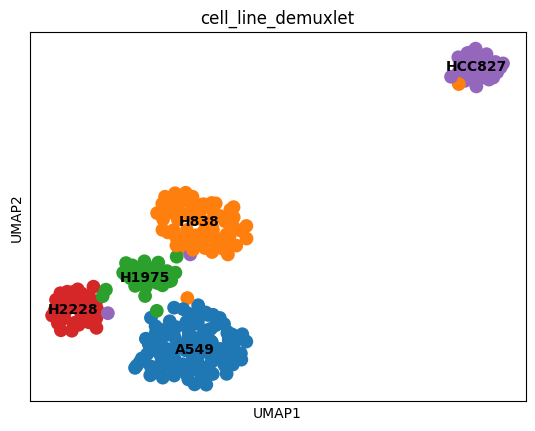

In [12]:
sc.pl.umap(
        adata,
        color=['cell_line_demuxlet'],
        legend_loc="on data",
        show=True,
        save=f"cl5_celseq2_p3.png"
    )